# Graphs for E-commerce dataset

<div style="background-color: #f0f7ff; border-left: 5px solid #5C9AFF; padding: 15px; border-radius: 5px; font-family: 'Roboto', sans-serif;">
    <p style="margin: 0; color: #002047;"><strong>Dataset:</strong> E-commerce dataset</p>
    <p style="margin: 5px 0; color: #002047;"><strong>Source:</strong> <a href="https://www.kaggle.com/datasets/carrie1/ecommerce-data" style="color: #5C9AFF;">Kaggle</a></p>
    <p style="margin: 0; color: #002047;"><strong>Author:</strong> Fishchenko Tamara</p>
</div>


### Styling headers and markdown cells
To improve the document's visual structure and readability, I chose Roboto as my main font, as well as a monochromatic blue gradient to headers.

In [4]:
%%html
<style>
@import url('https://fonts.googleapis.com');
.jp-RenderedHTMLCommon, .text_cell_render { 
    font-family: 'Roboto', sans-serif !important; 
    font-size: 15px !important;
    line-height: 1.6 !important;
}

.jp-RenderedHTMLCommon h1, .jp-RenderedHTMLCommon h2, 
.jp-RenderedHTMLCommon h3, .jp-RenderedHTMLCommon h4 {
    padding: 15px !important;
    border-radius: 8px !important;
    margin-top: 25px !important;
    margin-bottom: 10px !important;
    font-weight: 700 !important;
}

/* # Header 1 */
.jp-RenderedHTMLCommon h1 {
    background-color: #f0f7ff !important;
    border-left: 10px solid #5C9AFF !important;
    color: #002047 !important;
}

/* ## Header 2 */
.jp-RenderedHTMLCommon h2 {
    background-color: #e1ecf7 !important;
    border-left: 10px solid #528ae5 !important;
    color: #003366 !important;
}

/* ### Header 3 */
.jp-RenderedHTMLCommon h3 {
    background-color: #d6e4f2 !important;
    border-left: 10px solid #1e4f9a !important;
    color: #002047 !important;
}

/* #### Header 4 */
.jp-RenderedHTMLCommon h4 {
    background-color: #cbdcf0 !important;
    border-left: 10px solid #002047 !important;
    color: #001530 !important;
}
</style>

### Contents
1. [Data loading](#Data-loading)
2. [Graphs](#Graphs)
   - [Net revenue per month](#Net-revenue-per-month)
   - [Top 10 products](#Top-10-products)
      - [By quantity sold](#By-quantity-sold)
      - [By revenue](#By-revenue)
   - [Heatmaps by day of week](#Heatmaps-by-day-of-week)
      - [Revenue](#Revenue)
      - [Quantity](#Quantity)
   - [Heatmaps by hour of day](#Heatmaps-by-hour-of-day)
      - [Revenue](#Revenue)
      - [Quantity](#Quantity)
   - [Lifetime of cancelled/returned items](#Lifetime-of-cancelled/returned-items)
      - [Distribution of days](#Distribution-of-days)
      - [Distribution within first hour](#Distribution-within-first-hour)
3. [Results](#Results)
4. [References](#References)


### Objective

The main goal of this notebook is to:
1. Construct graphs
2. Find critical business insights
3. Provide strategic recommendations for optimising the retailer's operations

### Expected result

The expected result of this notebook is understandable and data-driven visualisations accompanied by clear, analytical descriptions and actionable business conclusions.

## Data loading

In [9]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
from IPython.display import display, HTML
from matplotlib.ticker import FuncFormatter

import warnings
warnings.filterwarnings('ignore')

# main formating for graphs
%matplotlib inline
sns.set_theme(style="whitegrid")
NICE_BLUE = "#69aeff"
DARK_BLUE = "#000d3f"

plt.rcParams['font.family'] = 'DejaVu Sans'

In [10]:
# used parquet not to lose specified data types
df_cleaned = pd.read_parquet("df_cleaned.parquet")

# products and non-products
df_products = df_cleaned.loc[~df_cleaned["IsNonProduct"]].copy()
df_non_products = df_cleaned.loc[df_cleaned["IsNonProduct"]].copy()

## Graphs

### Net revenue per month

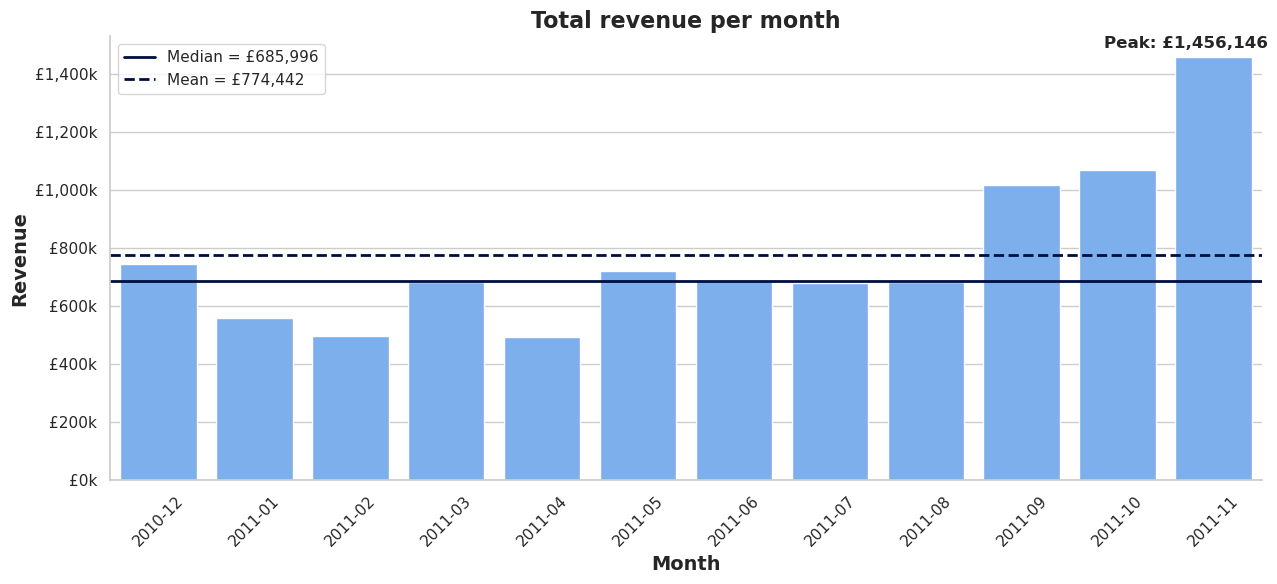

In [13]:
revenue_per_month = (
    df_cleaned.set_index("InvoiceDate")["Revenue"]
    .resample("M")
    .sum()
    .reset_index()
)

# for easier x-axis
revenue_per_month["YearMonth"] = revenue_per_month["InvoiceDate"].dt.strftime("%Y-%m")

# last month is incomplete, so it was removed
revenue_per_month = revenue_per_month[revenue_per_month["YearMonth"] != "2011-12"]

# for mean and median
mean_val = revenue_per_month["Revenue"].mean()
median_val = revenue_per_month["Revenue"].median()

# finding month and revenue for peak
peak_idx = revenue_per_month["Revenue"].idxmax()
peak_month = revenue_per_month.loc[peak_idx, "YearMonth"]
peak = revenue_per_month.loc[peak_idx, "Revenue"]

# creating bar chart
plt.figure(figsize=(13, 6))

ax = sns.barplot(
    data=revenue_per_month,
    x="YearMonth",
    y="Revenue",
    color=NICE_BLUE
)

# horizontal line for median
ax.axhline(
    median_val,
    linestyle="solid",
    linewidth=2,
    color=DARK_BLUE,
    label=f"Median = £{median_val:,.0f}"
)

# horizontal line for mean
ax.axhline(
    mean_val,
    linestyle="dashed",
    linewidth=2,
    color=DARK_BLUE,
    label=f"Mean = £{mean_val:,.0f}"
)

# highlighting peak
peak_x = list(revenue_per_month["YearMonth"]).index(peak_month)
ax.annotate(
    f"Peak: £{peak:,.0f}",
    xy=(peak_x, peak),
    xytext=(-20, 7),
    textcoords="offset points",
    ha="center",
    fontsize=12,
    weight="bold"
)

ax.set_title("Total revenue per month", fontsize=16, weight="bold")
ax.set_xlabel("Month", fontsize=14, weight="bold")
ax.set_ylabel("Revenue", fontsize=14, weight="bold")

# formatting y-axis
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'£{x/1000:,.0f}k'))


plt.xticks(rotation=45)
plt.legend()
sns.despine()
plt.tight_layout()
plt.show()

This histogram shows monthly revenue for the UK online retail dataset from December 2010 to November 2011, showing strong seasonality. At the start of 2011, revenue fell due to a post-holiday slowdown, then stabilised from May to August around the median. At the end of the year, sales surged, peaking in November at about £1.46 million, most likely caused by holiday preparations and bigger orders. December 2011 was not included in this graph due to insufficient data.

The fact that the mean (£774k) is higher than the median (£685k) suggests that the distribution is right-skewed because of the strong months at the end of the year, implying that the company is heavily dependent on those sales. This could cause a serious business risk as a large portion of annual revenue depends on a relatively short period of time (only 3 months), and if demand was to suddenly fall, the company would suffer significant losses. Moreover, such short periods of increased workload require more staffing and logistics operations, which can postpone deliveries of inventory and increase costs.

To prevent highlighted risks, the retailer should focus on improving sales in other timeframes by offering discounts and more diverse products to improve retention and to try to even out monthly sales, as well as having long-term contracts with agencies for busy months.

### Top 10 products

#### By quantity sold

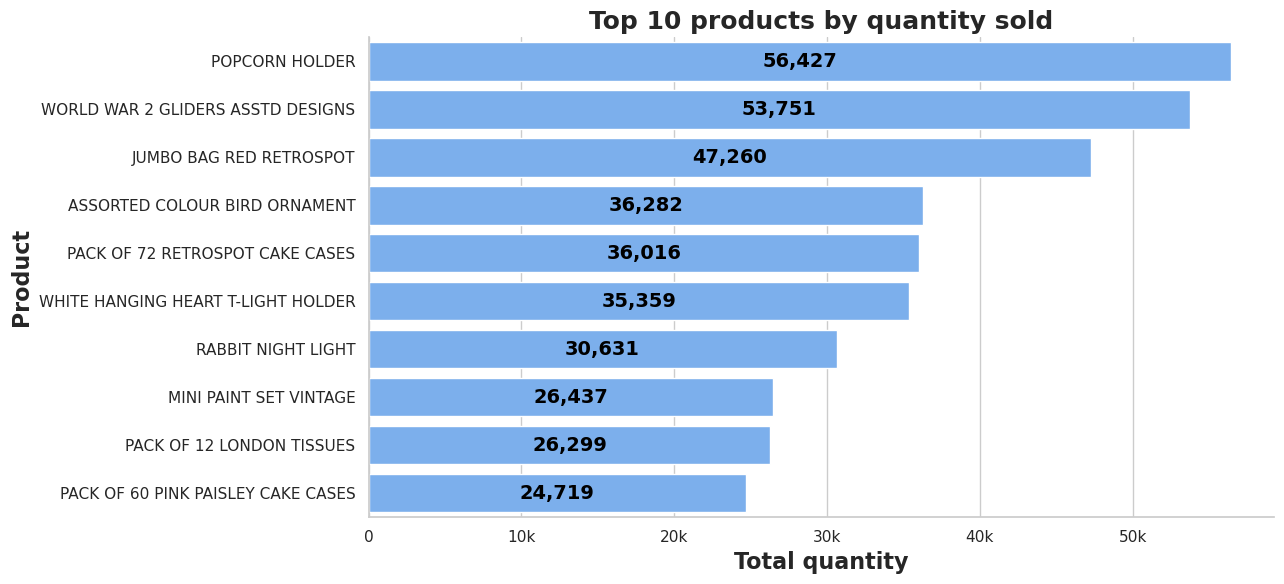

In [17]:
def format_thousands(x, pos):
    if x >= 1_000:
        return f"{x/1_000:.0f}k"
    return f"{x:.0f}"

# finding top 10 most sold products 
most_sold = (
    df_products.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(13, 6))

horizontal_bar = sns.barplot(
    data=most_sold,
    x="Quantity",
    y="Description",
    color=NICE_BLUE
)

horizontal_bar.set_title("Top 10 products by quantity sold", fontsize=18, weight="bold")
horizontal_bar.set_xlabel("Total quantity", fontsize=16, weight="bold")
horizontal_bar.set_ylabel("Product", fontsize=16, weight="bold")

# formating values on x-axis
horizontal_bar.xaxis.set_major_formatter(FuncFormatter(format_thousands))

# adding and formating labels inside bars
for container in horizontal_bar.containers:
    horizontal_bar.bar_label(
        container,
        labels=[f"{v:,.0f}" for v in container.datavalues],
        label_type="center",
        padding=0,
        fontsize=14,
        fontweight="bold",
        color = "black"
    )

sns.despine()
plt.tight_layout()
plt.show()

In [18]:
# converting descriptions to list
most_sold_descrip = most_sold["Description"].tolist()

# finding average price of top 10 products in order as in graph
most_sold_prices = (
    df_products[df_products["Description"].isin(most_sold_descrip)]
    .groupby("Description")["UnitPrice"]
    .mean()
    .reindex(most_sold_descrip)
    .reset_index()
)

most_sold_prices.columns = ["Product", "Average price (£)"]

print("Prices of top 10 products by quantity:")
display(most_sold_prices)

Prices of top 10 products by quantity:


,Product,Average price (£)
0,POPCORN HOLDER,1.035634
1,WORLD WAR 2 GLIDERS ASSTD DESIGNS,0.319963
2,JUMBO BAG RED RETROSPOT,2.470965
3,ASSORTED COLOUR BIRD ORNAMENT,1.722312
4,PACK OF 72 RETROSPOT CAKE CASES,0.758698
5,WHITE HANGING HEART T-LIGHT HOLDER,3.206805
6,RABBIT NIGHT LIGHT,2.381105
7,MINI PAINT SET VINTAGE,0.781564
8,PACK OF 12 LONDON TISSUES,0.446996
9,PACK OF 60 PINK PAISLEY CAKE CASES,0.743375


This bar chart shows top 10 products by quantity sold in the whole time period, with popcorn holder (56k), world war 2 gliders asstd designs (53k) and jumbo bag red retrosport (47k) being the bestsellers. From the table of prices, it can be seen that the most popular products are actually extremely cheap, with an average price of around £1.

According to Smith (2006), firms in low-margin markets often rely on volume-driven strategies, where large quantities of low-priced goods are sold to generate sufficient total profit, which fits observed data (business uses low-margin/high-volume pricing strategy). However, the paper also emphasises that low-margin firms should focus on bundling (e.g. discounted pack of cake cases and baking accessories) and cross-selling (e.g. pack of tissues and recommended container) rather than purely increasing volume.

#### By revenue

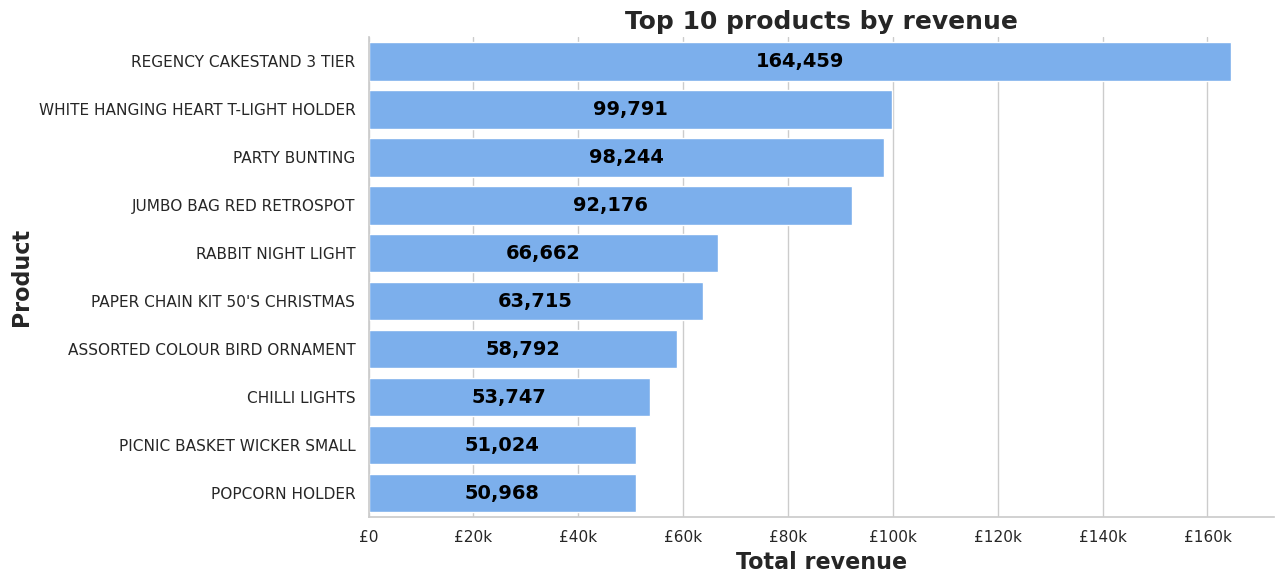

In [21]:
def format_currency(x, pos):
    if x >= 1_000_000:
        return f"£{x/1_000_000:.1f}M"
    if x >= 1_000:
        return f"£{x/1_000:.0f}k"
    return f"£{x:.0f}"

# finding top 10 highest-revenue products
top10_rev = (
    df_products.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(13, 6))

# creating bar chart
revenue_bar = sns.barplot(
    data=top10_rev,
    x="Revenue",
    y="Description",
    color=NICE_BLUE
)

revenue_bar.set_title("Top 10 products by revenue", fontsize=18, weight="bold")
revenue_bar.set_xlabel("Total revenue", fontsize=16, weight="bold")
revenue_bar.set_ylabel("Product", fontsize=16, weight="bold")

# formating values on x-axis
revenue_bar.xaxis.set_major_formatter(FuncFormatter(format_currency))

# adding and formating labels inside bars
for container in revenue_bar.containers:
    revenue_bar.bar_label(
        container,
        labels=[f"{v:,.0f}" for v in container.datavalues],
        label_type="center",
        padding=0,
        fontsize=14,
        fontweight="bold",
        color="black"
    )

sns.despine()
plt.tight_layout()
plt.show()

In [22]:
# converting descriptions to list
most_sold_descrip = top10_rev["Description"].tolist()

# finding average price of top 10 products in order as in graph
most_sold_prices = (
    df_products[df_products["Description"].isin(most_sold_descrip)]
    .groupby("Description")["UnitPrice"]
    .mean()
    .reindex(most_sold_descrip)
    .reset_index()
)

most_sold_prices.columns = ["Product", "Average price (£)"]

print("Prices of top 10 products by revenue:")
display(most_sold_prices)

Prices of top 10 products by revenue:


,Product,Average price (£)
0,REGENCY CAKESTAND 3 TIER,13.806377
1,WHITE HANGING HEART T-LIGHT HOLDER,3.206805
2,PARTY BUNTING,5.782134
3,JUMBO BAG RED RETROSPOT,2.470965
4,RABBIT NIGHT LIGHT,2.381105
5,PAPER CHAIN KIT 50'S CHRISTMAS,3.356533
6,ASSORTED COLOUR BIRD ORNAMENT,1.722312
7,CHILLI LIGHTS,6.750340
8,PICNIC BASKET WICKER SMALL,10.194202
9,POPCORN HOLDER,1.035634


This bar chart shows top 10 products by revenue in the whole time period, with regency cakstand 3 tier (£164k), white hanging heart t-light holder (£99k) and party bunting (£98k) being the most profitable. These products have much higher prices compared to the most frequently bought ones. 

Although low-cost items provide high number of transactions, the majority of revenue is generated by products priced between £3.00 and £14.00. This suggests that increasing the average value per purchase may be more effective for revenue growth than only increasing transaction frequency.

---
Overall, cheap products are effective in attracting customers but revenue depends heavily on mid-priced items. According to Kaul and Rao (1995), consumers make choices based on the basis of perceptual product attributes that can be influenced by various factors under the firm's control such as product design and marketing mix of the product, meaning that low prices are not enough to maximise profitability.

To improve sales, the business should reposition its mid-range and expensive products, aligning with consumer preferences and values. This can be achieved through cross-selling and bundling to make more expensive options more appealing, while also ensuring proper product positioning. Additionally, it should focus on improving product attributes and converting them into effective marketing mix decisions to shift demand from low-priced products toward more profitable alternatives.

### Heatmaps by day of week 

In [26]:
df_heatmaps = df_products[
    (df_products["Quantity"] >= 0) &
    (df_products["IsReturn"] == False)
].copy()

df_heatmaps["YearMonth"] = df_heatmaps["InvoiceDate"].dt.strftime("%Y-%m")

# removing last month
df_heatmaps = df_heatmaps[df_heatmaps["YearMonth"] != "2011-12"]

# ordering days and months
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
month_order = [ "December", "January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November"]

# making them categories
df_heatmaps["DayOfWeek"] = pd.Categorical(df_heatmaps["DayOfWeek"], categories=weekday_order, ordered=True)
df_heatmaps["MonthName"] = pd.Categorical(df_heatmaps["MonthName"], categories=month_order, ordered=True)

# data for revenue heatmap
revenue_data = (
    df_heatmaps.groupby(["DayOfWeek", "MonthName"])["Revenue"]
    .sum()
    .unstack()
    .fillna(0)
)

# data for quantity heatmap
quantity_data = (
    df_heatmaps.groupby(["DayOfWeek", "MonthName"])["Quantity"]
    .sum()
    .unstack()
    .fillna(0)
)

#### Revenue

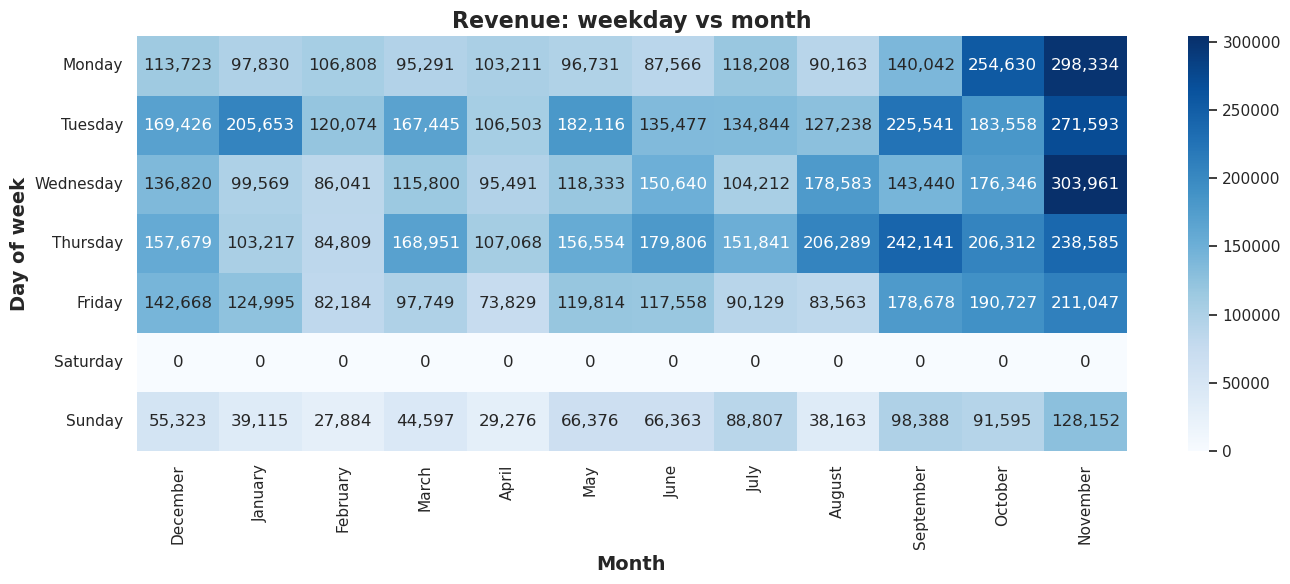

In [28]:
plt.figure(figsize=(14, 6))

sns.heatmap(
    revenue_data,
    cmap="Blues",
    annot=True,
    fmt=",.0f"
)

plt.title("Revenue: weekday vs month", fontsize=16, weight="bold")
plt.xlabel("Month", fontsize=14, weight="bold")
plt.ylabel("Day of week", fontsize=14, weight="bold")

plt.tight_layout()
plt.show()

#### Quantity

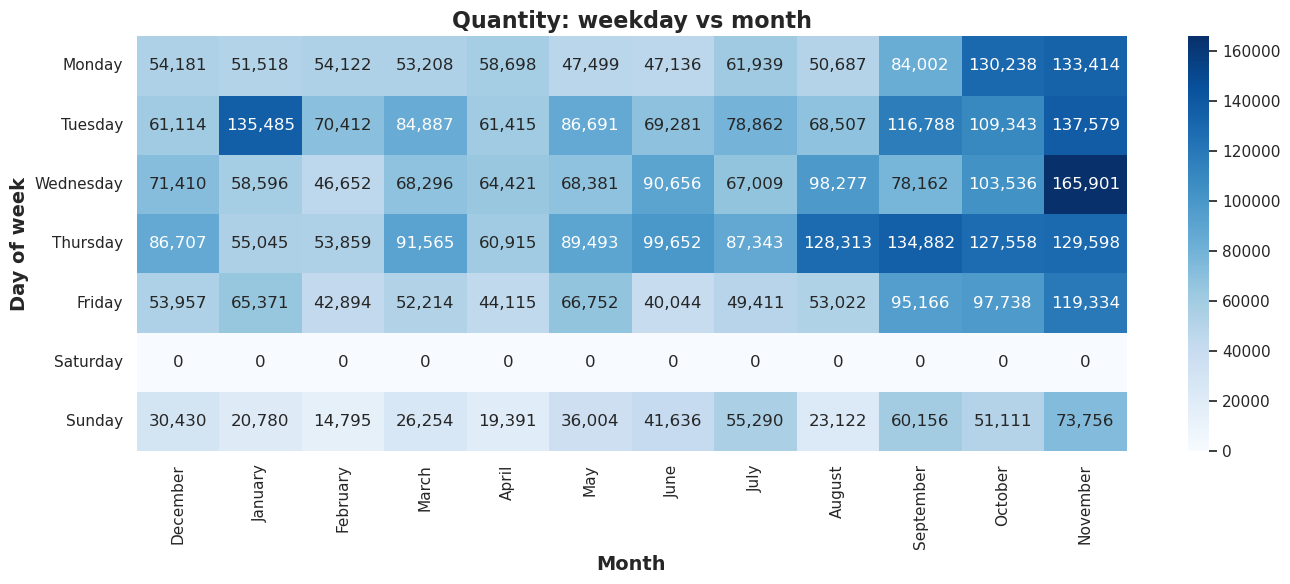

In [30]:
plt.figure(figsize=(14, 6))

sns.heatmap(
    quantity_data,
    cmap="Blues",
    annot=True,
    fmt=",.0f"
)

plt.title("Quantity: weekday vs month", fontsize=16, weight="bold")
plt.xlabel("Month", fontsize=14, weight="bold")
plt.ylabel("Day of week", fontsize=14, weight="bold")

plt.tight_layout()
plt.show()

These is an outlier on Tuesday January in Quanity.

In [32]:
# we need to check only Tuesdays January for anomalies
january_tuesday = df_heatmaps[
    (df_heatmaps["MonthName"] == "January") & 
    (df_heatmaps["DayOfWeek"] == "Tuesday")
]

# finding Tuesday with most transactions
tuesday_most_quanity = january_tuesday.groupby(january_tuesday["InvoiceDate"].dt.date)["Quantity"].sum().idxmax()

# finding top products by quantity on this day
top_products = (
    df_heatmaps[df_heatmaps["InvoiceDate"].dt.date == tuesday_most_quanity]
    .groupby("Description")["Quantity"]
    .sum()
    .nlargest(10)
)

print("Tuesday January with most transactions:", tuesday_most_quanity)
print(top_products)

Tuesday January with most transactions: 2011-01-18
Description
MEDIUM CERAMIC TOP STORAGE JAR         74215
BROCADE RING PURSE                       720
HANGING JAM JAR T-LIGHT HOLDER           216
72 SWEETHEART FAIRY CAKE CASES           144
BLUE PARTY BAGS                          144
COLOUR GLASS T-LIGHT HOLDER HANGING      144
SET/20 RED RETROSPOT PAPER NAPKINS       122
60 TEATIME FAIRY CAKE CASES              120
SET OF 9 HEART SHAPED BALLOONS           109
CHARLOTTE BAG SUKI DESIGN                 91
Name: Quantity, dtype: int64


In [33]:
# getting information about purchases on January 18, 2011
most_sold_Jan18 = df_heatmaps[df_heatmaps["InvoiceDate"].dt.date == tuesday_most_quanity].nlargest(1, "Quantity")

# finding average price
average_price = df_heatmaps[df_heatmaps["Description"] == most_sold_Jan18["Description"].iloc[0]]["UnitPrice"].mean()

print("Most sold product:", most_sold_Jan18["Description"].iloc[0])
print("CustomerID:", most_sold_Jan18["CustomerID"].iloc[0])
print(f"Price: £{most_sold_Jan18["UnitPrice"].iloc[0]}")
print(f"Average price: £{average_price:.2f}")

Most sold product: MEDIUM CERAMIC TOP STORAGE JAR
CustomerID: 12346.0
Price: £1.04
Average price: £1.45


These heatmaps illustrate the distribution of revenue and sales quantity across weekdays and months, revealing clear seasonal and operational trends throughout the year with both revenue and quantity growing significantly in the September - November. I chose not to include December 2011 since the data in it artificially made December appear to be the most profitable month, despite data being incomplete.

November is the most active month with the highest values on nearly all weekdays, where November Wednesday generated most revenue (£303,961) and quantity (165,901), once again proving the autumn to be the company’s primary revenue-generating season. Meanwhile, Thursdays can be considered the most stable weekday with figures slowly increasing towards the end of the year. 

It can also be noticed that Tuesday January appears to be a classic example of low-margin and high-volume movement. However, upon deeper inspection, it was determined to be an isolated outlier, which was caused by a single transaction of 74215 MEDIUM CERAMIC TOP STORAGE JAR, valued only at £1.04 compared to the average of £1.45, potentially caused by purchasing a large volume or a predetermined deal rather than post-holiday sales.

From the description of the dataset, it is known that the studied business is a retailer with its main clients being wholesalers. Thus, it follows a B2B business model, which can be confirmed by no activity on Saturdays and the lowest figures on Sundays, while the majority of sales happen during weekdays.

Using this information, the following can be suggested:
1. The most optimal day for technical maintenance for online platform or processing in warehouses is Saturday to ensure nothing gets disrupted during peak sales periods.
2. Tuesday January spike supports the idea of focusing advertisement and discounts in January on offloading unsold items for cheaper prices to clear warehouse space.
3. Since February and April have the lowest activity, encouraging workers to take their annual leave in these months would reduce the risk of lack of personnel during peak seasons. Reducing staffing to a minimum on Sundays is another way to cut costs.
4. To reduce pressure on warehouses and logistics during November, the business should try to even out monthly orders by offering bulk discounts a few weeks earlier to shift part of the orders to October.

### Heatmaps by hour of day 

In [36]:
revenue_data = (
    df_heatmaps.groupby(["DayOfWeek", "Hour"])["Revenue"]
    .sum()
    .unstack()
    .fillna(0)
)

quantity_data = (
    df_heatmaps.groupby(["DayOfWeek", "Hour"])["Quantity"]
    .sum()
    .unstack()
    .fillna(0)
)

#### Revenue

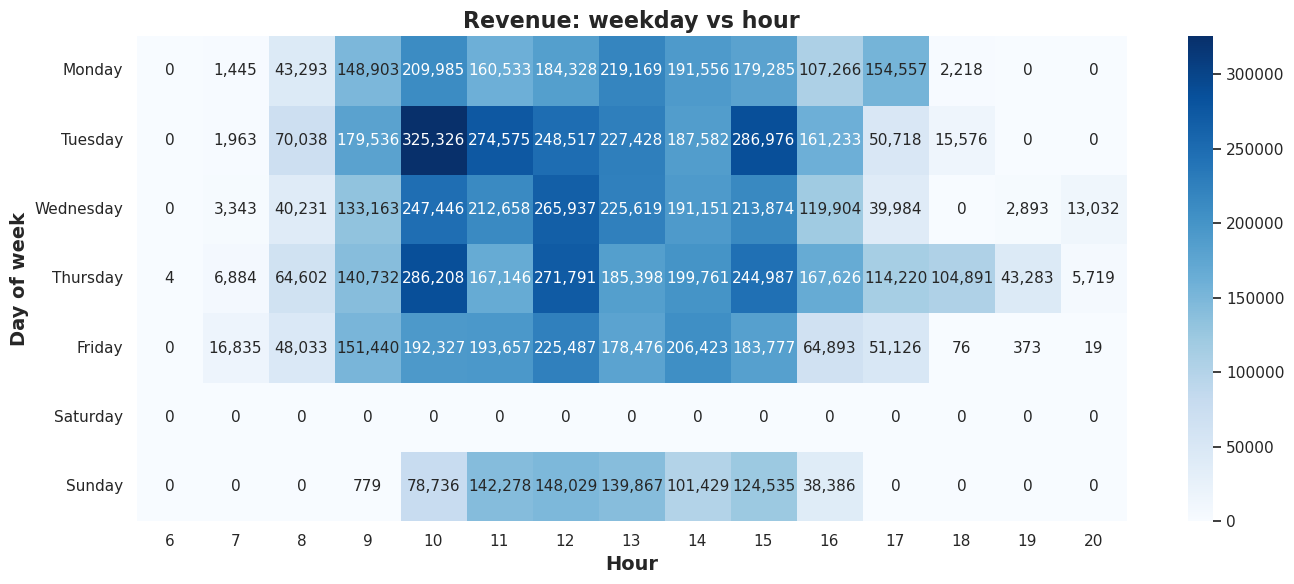

In [38]:
plt.figure(figsize=(14, 6))

sns.heatmap(
    revenue_data,
    cmap="Blues",
    annot=True,
    fmt=",.0f",
    annot_kws={"size": 11}
)

plt.title("Revenue: weekday vs hour", fontsize=16, weight="bold")
plt.xlabel("Hour", fontsize=14, weight="bold")
plt.ylabel("Day of week", fontsize=14, weight="bold")

plt.tight_layout()
plt.show()

#### Quantity

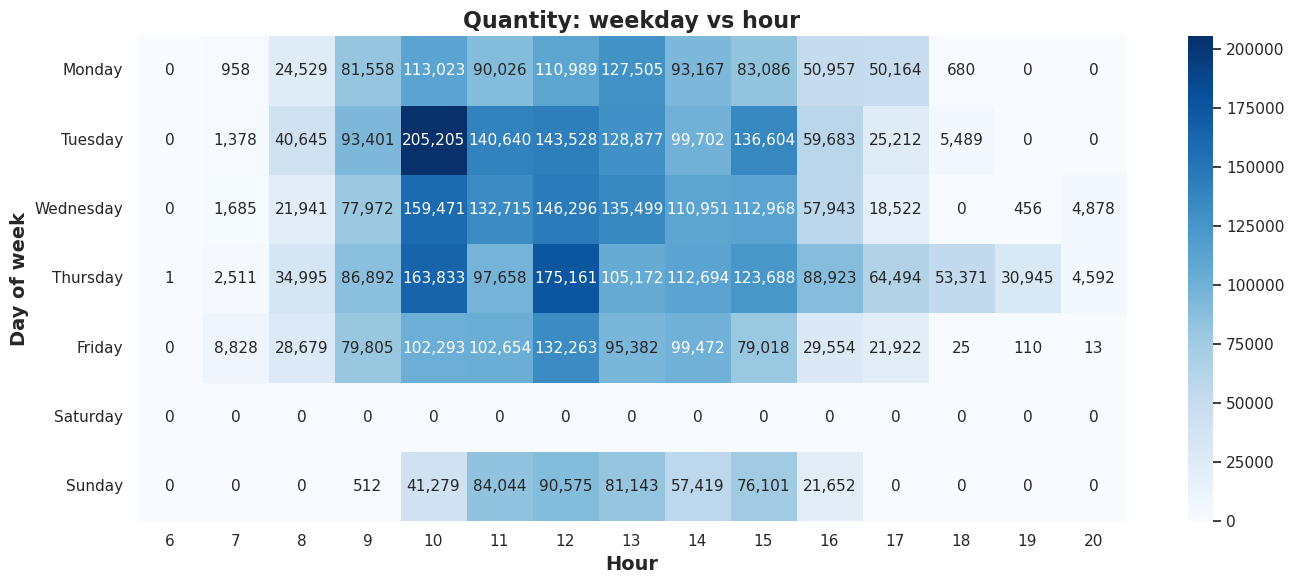

In [40]:
plt.figure(figsize=(14, 6))

sns.heatmap(
    quantity_data,
    cmap="Blues",
    annot=True,
    fmt=",.0f",
    annot_kws={"size": 11}
)

plt.title("Quantity: weekday vs hour", fontsize=16, weight="bold")
plt.xlabel("Hour", fontsize=14, weight="bold")
plt.ylabel("Day of week", fontsize=14, weight="bold")

plt.tight_layout()
plt.show()

---
These heatmaps illustrate the distribution of revenue and sales quantity across weekdays and hours, revealing hourly operational patterns. Daily activity spanned from 7 AM to 4 PM, after which volume diminished rapidly, while the majority of it happened between 10 AM and 3 PM, again confirming the B2B business model where wholesalers placed orders during standard office hours. There is no data on Saturdays and Sunday was the least active day with sales peaking at 12 PM.

The strongest performance was observed on Tuesdays, Thursdays and Fridays, especially during late morning and early afternoon. Both graphs reached their highest figures on Tuesdays at 10 AM. These indicate that customer purchasing activity was most intense at the beginning and middle of the business week but decreases by the end of the business day. 

Meanwhile, Thursdays maintained a high volume of transactions until 6 PM and smaller one until 8 PM, which shows clients likely rushed to finalise their large orders on Thursdays to ensure their orders were processed before weekends.

Using this information, the following can be suggested:
1. All technical maintenance for online platform should be either done on Saturdays (as it was suggested previously) or between 9 PM and 6 AM, when customers are inactive.
2. Before the main activity begins, stock arrival notifications and advertisements should be sent to clients between 8:30 AM and 9:30 AM to influence their purchasing decisions with attractive deals.

### Lifetime of cancelled/returned items

#### Distribution of days

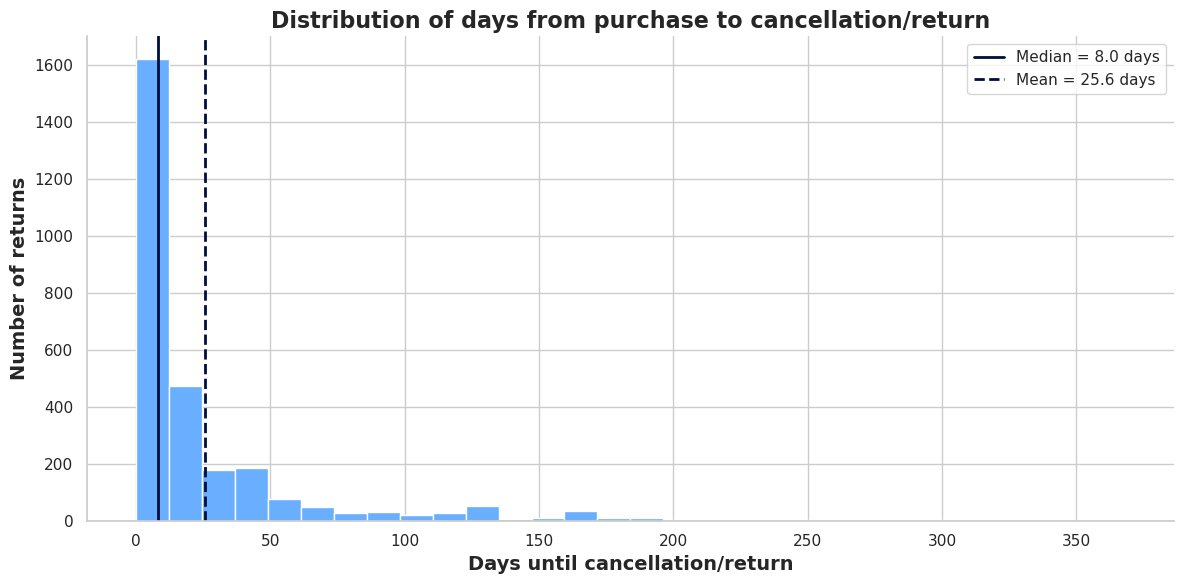

In [44]:
# separating sales and returns
sales = df_products[~df_products["IsReturn"]].copy()
returns = df_products[df_products["IsReturn"]].copy()

# changing sign of return quantities
returns["Quantity"] = returns["Quantity"].abs()

# matching returns with original purchases
return_sale_pairs = (
    returns.merge(
        sales,
        left_on=["CustomerID", "Description", "UnitPrice",
                 "StockCode", "Country", "Quantity"],
        right_on=["CustomerID", "Description", "UnitPrice",
                  "StockCode", "Country", "Quantity"],
        suffixes=("_ret", "_sale")
    )
    .query("InvoiceDate_ret > InvoiceDate_sale")
    .sort_values("InvoiceDate_sale")
    .drop_duplicates(
        subset=["CustomerID", "StockCode",
                "Quantity", "InvoiceDate_ret"],
        keep="last"
    )
)

# finding days until return
return_sale_pairs["Days_till_ret"] = (return_sale_pairs["InvoiceDate_ret"] - return_sale_pairs["InvoiceDate_sale"]).dt.days

# finding mean and median
mean_days = return_sale_pairs["Days_till_ret"].mean()
median_days = return_sale_pairs["Days_till_ret"].median()


plt.figure(figsize=(12, 6))

ax = sns.histplot(
    return_sale_pairs["Days_till_ret"],
    bins=30,
    color=NICE_BLUE,
    alpha=1.0
)

# median
ax.axvline(
    median_days,
    color=DARK_BLUE,
    linestyle="solid",
    linewidth=2,
    label=f"Median = {median_days:.1f} days"
)

# mean
ax.axvline(
    mean_days,
    color=DARK_BLUE,
    linestyle="dashed",
    linewidth=2,
    label=f"Mean = {mean_days:.1f} days"
)

# titles and labels
ax.set_title("Distribution of days from purchase to cancellation/return", fontsize=16, weight="bold")
ax.set_xlabel("Days until cancellation/return", fontsize=14, weight="bold")
ax.set_ylabel("Number of returns", fontsize=14, weight="bold")

plt.legend()
sns.despine()
plt.tight_layout()
plt.show()

#### Distribution within first hour

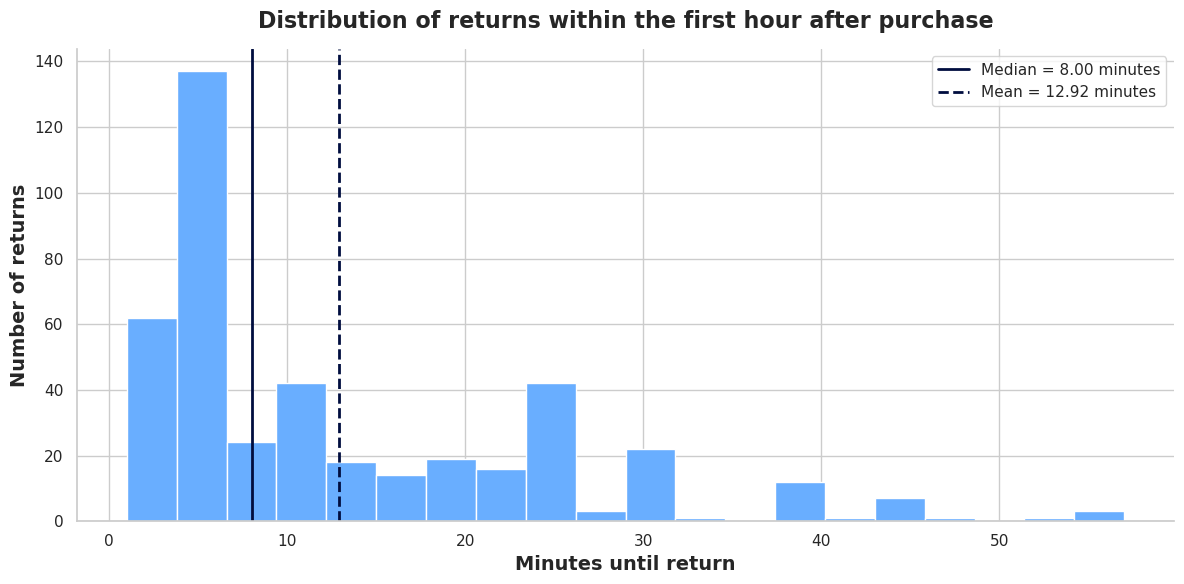

In [46]:
return_sale_pairs["Minutes_till_ret"] = (
    return_sale_pairs["InvoiceDate_ret"] - return_sale_pairs["InvoiceDate_sale"]
).dt.total_seconds() / 60

# keep only returns within first hour
first_hour = return_sale_pairs[return_sale_pairs["Minutes_till_ret"] <= 60].copy()

mean_hours = first_hour["Minutes_till_ret"].mean()
median_hours = first_hour["Minutes_till_ret"].median()

plt.figure(figsize=(12, 6))

ax = sns.histplot(
    first_hour["Minutes_till_ret"],
    bins=20,
    color=NICE_BLUE,
    alpha=1.0
)

ax.axvline(
    median_hours,
    linestyle="solid",
    linewidth=2,
    color=DARK_BLUE,
    label=f"Median = {median_hours:.2f} minutes"
)

ax.axvline(
    mean_hours,
    linestyle="dashed",
    linewidth=2,
    color=DARK_BLUE,
    label=f"Mean = {mean_hours:.2f} minutes"
)

ax.set_title("Distribution of returns within the first hour after purchase", fontsize=16, weight="bold", pad=15)
ax.set_xlabel("Minutes until return", fontsize=14, weight="bold")
ax.set_ylabel("Number of returns", fontsize=14, weight="bold")

plt.legend()
sns.despine()
plt.tight_layout()
plt.show()

In [47]:
total_returns = len(return_sale_pairs)
minutes = return_sale_pairs["Minutes_till_ret"]
days = return_sale_pairs["Days_till_ret"]

# info about number of returns in some period of time
summary = pd.DataFrame({
    "Period": [
        "Within 1st hour",
        "Day 0",
        "Day 1",
        "Day 2",
        "Day 3",
        "Days 4-7",
        "Days 8-30",
        "Over 30 days",
    ],
    "Number of returns": [
        (minutes <= 60).sum(),
        (days == 0).sum(),
        (days == 1).sum(),
        (days == 2).sum(),
        (days == 3).sum(),
        ((days >= 4) & (days <= 7)).sum(),
        ((days >= 8) & (days <= 30)).sum(),
        (days > 30).sum(),
    ]
})

summary["Percentage of returns"] = (summary["Number of returns"] / total_returns * 100)
summary

,Period,Number of returns,Percentage of returns
0,Within 1st hour,425,14.844569
1,Day 0,641,22.389102
2,Day 1,84,2.933985
3,Day 2,164,5.728257
4,Day 3,116,4.051694
5,Days 4-7,366,12.783793
6,Days 8-30,838,29.269997
7,Over 30 days,654,22.843171


These histograms show the distribution of lifetimes of returned items in days and within the first hour. As it can be observed, both are highly right-skewed, where the mean is bigger than the median due to long tails.

Rosenzweig and Gilovich (2012) conducted consumer psychology research for material and experiential purchases and what types the types of regrets they elicit. The retailer sells material good which generate high buyer's remorse because they are highly "interchangeable", meaning after the purchase consumers can find better substitutes (especially considering the studied company is an online retailer), leading to short lifetimes of transactions. This idea is suitable for observed data since from the table, 14.84% of all returns happened within the first hour (the median is equal only to 8 minutes) and 22.39% within the first day. Such fast returns are unlikely to be a result of product dissatisfaction, but instead they usually reflect spontaneous or accidental orders, errors in the system (e.g. duplicated or invalid orders removed by the retailer himself) or buyer's remorse. 

Days 8-30 account for 29.3% of all returns. However, about 23% of them happened after 30 days. Although there is a probability that some were cancelled due to long deliveries or some logistics errors, most of them most likely were received and evaluated by customers, leading to a deliberate return within the return policy timeframe. One of the potential reasons for this is that wholesalers (main clients) had to clear their own shelves or offload seasonal stock that did not sell as anticipated, in order to compensate for their losses by getting their money back. Another possibility is functional issues, such as defects or poor quality.

Using this information, the following can be suggested:
1. Since many orders are cancelled within the first 10 minutes, the company can choose to process all orders with a 30-minute delay (for consumers to have time to cancel) to reduce the pressure on warehouses.
3. For returns after over 30 days without a valid reason (defects, damages, etc.), 10-15% fines can be imposed to partially compensate the staffing and shipping costs. This would also shift the financial burden of overstocking back onto the wholesale clients.
4. Limiting the number of returned items per quarter without a valid reason can also be useful because this would prevent clients from returning unsold seasonal stock to recover their own losses and make them more considerate of their orders for peak seasons.
5. According to Rosenzweig and Gilovich (2012), experiential goods are less likely to cause buyer's remorse. Thus, emphasising the product's lifestyle and emotional benefits can significantly lower same-day returns and even provide ideas to wholesalers on how to advertise to their own clients when they resell which could potentially lower the amount of cancellations after most active seasons.

## Results
Overall, this notebook focuses of visual representation of e-commerce dataset. The following was done:
* Found revenue trends, most sold and revenue-generating products, disctibutions of revenue, quantity and cancellations.
* Described main features and details of each graphs.
* Identified main business insights for each section.
* Made business data-driven suggestions with some ideas provided by offical documents.

## References
1. Carrie. *E-commerce Data*. https://www.kaggle.com/datasets/carrie1/ecommerce-data
1. *Module: display — IPython 9.11.0 documentation*. IPython. https://ipython.readthedocs.io/en/stable/api/generated/IPython.display.html
5. *matplotlib.pyplot.axhline — Matplotlib 3.10.8 documentation*. Matplotlib. https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.axhline.html
6. *matplotlib.pyplot.axvline — Matplotlib 3.10.8 documentation*. Matplotlib. https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.axvline.html
7. *matplotlib.axes.Axes.annotate — Matplotlib 3.10.8 documentation*. Matplotlib. https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.annotate.html
8. *matplotlib.axis.Axis.set_major_formatter — Matplotlib 3.10.8 documentation*. Matplotlib. https://matplotlib.org/stable/api/_as_gen/matplotlib.axis.Axis.set_major_formatter.html
9. *pandas.DataFrame.reindex — pandas 2.2.3 documentation*. (2024). Pydata.org. https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.reindex.html
10. *seaborn.despine — seaborn 0.13.2 documentation*. Seaborn. https://seaborn.pydata.org/generated/seaborn.despine.html
11. Головин, Д. (2023, April 6). *Полезные методы работы с данными в Pandas. Часть 1*. Хабр. https://habr.com/ru/companies/otus/articles/727222/
1. Smith, G. E. (2006). Leveraging profitability in low‐margin markets. Journal of Product & Brand Management, 15(6), 358-366.
2. Kaul, A., & Rao, V. R. (1995). *Research for product positioning and design decisions: An integrative review*. International Journal of research in Marketing, 12(4), 293-320.
3. *pandas.DataFrame.unstack — pandas 1.5.2 documentation*. (n.d.). Pandas.pydata.org. https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.unstack.html
4. *Seaborn Heatmap - A comprehensive guide*. GeeksforGeeks (2020, November 10). https://www.geeksforgeeks.org/python/seaborn-heatmap-a-comprehensive-guide/
5. *pandas.DataFrame.idxmax — pandas documentation*. (2026). Pydata.org. https://pandas.pydata.org/pandas-docs/dev/reference/api/pandas.DataFrame.idxmax.html
6. *pandas.DataFrame.nlargest — pandas 1.2.4 documentation*. (n.d.). Pandas.pydata.org. https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.nlargest.html
7. Waskom, M. (n.d.). *seaborn.histplot — seaborn 0.11.2 documentation*. Seaborn.pydata.org. https://seaborn.pydata.org/generated/seaborn.histplot.html
8. *pandas.DataFrame.merge — pandas 1.3.4 documentation*. (n.d.). Pandas.pydata.org. https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.merge.html
9. Rosenzweig, E., & Gilovich, T. (2012). *Buyer's remorse or missed opportunity? Differential regrets for material and experiential purchases*. Journal of personality and social psychology, 102(2), 215.